> # ⚠️ SUPERSEDED — do not run for reported numbers
>
> Use **`tiger_corrected_run.ipynb`** instead.
>
> This notebook runs against `master`, where the repair-measurement harness is
> broken in four independent ways (A1, A3/A3b, A5, A8 in `code_fixes/FIXES.md`).
> Numbers produced here cannot be reproduced or defended:
>
> * the "No Gamma Gate" ablation runs the identical configuration as Full System;
> * the random baseline is unseeded and not uniform;
> * "Restoration Accuracy" scores colour only — image repairs are not scored at all;
> * per-signal precision counts any dirty row as a hit.
>
> It also calls `--vlm-judge`, whose model ID is unverified (A2). On the fixed
> branch that now raises rather than silently vetoing every repair.
>
> Two statements in the cells below are simply wrong: the Arbiter is **logistic
> regression**, not "gradient boosting (XGBoost)"; and `data/sample/` could not
> be built at all until D5 was fixed.
>
> Kept for provenance — this is the notebook that produced the current tables.

# 🐯 TIGeR Kaggle Workflow
Welcome to the complete TIGeR (Text-Image Generative Repair) pipeline.

This notebook is broken down step-by-step so you can see exactly how the AI identifies, routes, and repairs multimodal errors in ecommerce catalogues.


## 📖 Glossary of Terms & Jargon

Before we begin, here is a quick guide to the terminology used in this pipeline:

* **TIGeR**: Text-Image Generative Repair (the name of this system).
* **V2T (Vision-to-Text)**: A repair strategy where we *fix the text* to match the image (e.g., updating the description to say "red shirt" instead of "blue shirt" because the image is clearly red).
* **T2V (Text-to-Vision)**: A repair strategy where we *replace the image* because the text description is correct, but the wrong photo was uploaded.
* **Sieve (Error Detection)**: The initial scanner that looks at the whole catalogue and flags products where the image and text do not seem to match.
* **Arbiter (Routing)**: The AI decision-maker. It looks at the flagged products and decides the safest way to fix them (V2T vs. T2V vs. Escalate to Human).
* **Solver (Repair Execution)**: The system that carries out the Arbiter's instructions (applying text patches or swapping images).
* **VLM Judge (Vision-Language Model)**: An advanced AI (like Google Gemini) that acts as a final safety checkpoint. It looks at the repaired product and vetoes the repair if it doesn't make sense.
* **Generative Fallback**: If the Arbiter wants to replace an image (T2V) but cannot find a valid replacement in the catalogue, the system uses Stable Diffusion to synthetically generate a brand new, mathematically perfect image from scratch.
* **LOO (Leave-One-Out) Masking**: A detective technique used by the system to figure out what is wrong. It hides one word at a time from the text to see if the image-text match improves, allowing it to pinpoint the exact wrong word.



### Step 0: Clone the Repository
First, we download the latest code from GitHub and set up our working directory.


In [1]:
!rm -rf TIGeR-Text-Image-Generative-Repair
!git clone https://github.com/namaray/TIGeR-Text-Image-Generative-Repair.git
%cd TIGeR-Text-Image-Generative-Repair
!pip install -e ".[dev,vlm,gen]" -q

Cloning into 'TIGeR-Text-Image-Generative-Repair'...
remote: Enumerating objects: 744, done.
remote: Counting objects: 100% (744/744), done.
remote: Compressing objects: 100% (524/524), done.
remote: Total 744 (delta 290), reused 656 (delta 203), pack-reused 0 (from 0)
Receiving objects: 100% (744/744), 3.36 MiB | 26.64 MiB/s, done.
Resolving deltas: 100% (290/290), done.
/kaggle/working/TIGeR-Text-Image-Generative-Repair
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tiger (pyproject.toml) ... done


### Step 1: Environment Setup
We load the Gemini API key from Kaggle Secrets so our VLM Judge can verify complex repairs.


In [2]:
from kaggle_secrets import UserSecretsClient
import os

try:
    user_secrets = UserSecretsClient()
    gemini_key = user_secrets.get_secret("gemini api")
    os.environ["GEMINI_API_KEY"] = gemini_key
    print("✅ Gemini API Key loaded successfully from Kaggle Secrets!")
except Exception as e:
    print("❌ Failed to load Gemini API Key. Did you add it to Kaggle Secrets? Error:", e)

✅ Gemini API Key loaded successfully from Kaggle Secrets!


## Phase 1: Data Generation
### Step 2: Generate Synthetic Catalogue (`synthgen`)
Here we create a perfectly clean, ground-truth catalogue of synthetic products (shirts, shoes, bags, hats) and render their images. We also explicitly inject a highly unique item (a magenta velvet spacesuit) to guarantee a generative fallback scenario later.


In [3]:
!python -m tiger.cli import-fashion --source /kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset

Importing Fashion Product Images from /kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset...
category  split      
bags      calibration    248
          report         249
hats      calibration     14
          report          25
shirts    calibration    723
          report         736
shoes     calibration    515
          report         490


## Phase 2: AI Calibration
### Step 3: Calibrate Sieve Thresholds (`calibrate`)
The system analyzes the clean data to learn what "normal" similarity scores look like for different product categories, setting automatic thresholds for error detection.


In [4]:
!python -m tiger.cli calibrate

locked thresholds -> /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_locked_thresholds.json
LOO calibration -> /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_loo_calibration.json
verify epsilon=0.0411 (by category: {'shirts': 0.0393, 'bags': 0.0472, 'shoes': 0.0383, 'hats': 0.0442}) -> /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_verify_calibration.json


### Step 4: Train the AI Arbiter (`train-arbiter`)
We train a lightweight gradient boosting model (XGBoost) to act as the AI Arbiter. This model learns to look at error evidence and decide the safest repair strategy (e.g., Fix Text, Replace Image, or Escalate to Human).


In [5]:
!python -m tiger.cli train-arbiter

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/processed/noisy_report_cal_seed1007.parquet
{
  "seed": 1007,
  "copies_per_row": 1,
  "rates": {
    "swap_image": 0.1,
    "swap_image_same_category": 0.03,
    "color_flip": 0.06,
    "near_color_flip": 0.02,
    "material_flip": 0.02,
    "attribute_drop": 0.02,
    "title_contradiction": 0.02,
    "mixed_swap_color": 0.02,
    "missing_image": 0.01
  },
  "rows_total": 1500,
  "rows_noisy": 450,
  "by_label": {
    "clean": 1050,
    "mutate_text": 210,
    "swap_image": 195,
    "mixed": 30,
    "missing_image": 15
  },
  "by_subtype": {
    "swap_image": 150,
    "color_flip": 90,
    "swap_image_same_category": 45,
    "material_flip": 30,
    "near_color_flip": 30,
    "title_contradiction": 30,
    "mixed_swap_color": 30,
    "attribute_drop": 30,
    "missing_image": 15
  },
  "self_verified": true
}


📊 Stage 1: Error Detection Complete
--------------------------------------------------
Out of 1500 products scann

### Step 5: Calibrate Decision Fusion (`calibrate-fusion`)
We tune the confidence gating of the Arbiter to ensure it hits a strict 85% precision floor, meaning it only automatically repairs items when it is highly confident.


In [6]:
!python -m tiger.cli calibrate-fusion

precision floor 0.85; calibrated on 12000 labelled rows
  flag_probe_color           precision=0.882 fired=1109 z>=2.5
  flag_probe_material        precision=None fired=0 z>=4.0 QUARANTINED
  flag_probe_pattern         precision=None fired=0 z>=4.0 QUARANTINED
  flag_low_sim               precision=0.888 fired=1712
  flag_text_out_of_domain    precision=1.0 fired=240
  flag_title_contradiction   precision=0.477 fired=880
wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_fusion.json


## Phase 3: The Repair Pipeline
### Step 6: Inject Anomalies (`noise`)
Now we intentionally corrupt the clean catalogue! We drop images, swap images with other products, and mutate text attributes to simulate real-world e-commerce errors.


In [7]:
!python -m tiger.cli noise --seed 7

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/processed/noisy_report_seed7.parquet
{
  "seed": 7,
  "copies_per_row": 1,
  "rates": {
    "swap_image": 0.1,
    "swap_image_same_category": 0.03,
    "color_flip": 0.06,
    "near_color_flip": 0.02,
    "material_flip": 0.02,
    "attribute_drop": 0.02,
    "title_contradiction": 0.02,
    "mixed_swap_color": 0.02,
    "missing_image": 0.01
  },
  "rows_total": 1500,
  "rows_noisy": 450,
  "by_label": {
    "clean": 1050,
    "mutate_text": 210,
    "swap_image": 195,
    "mixed": 30,
    "missing_image": 15
  },
  "by_subtype": {
    "swap_image": 150,
    "color_flip": 90,
    "swap_image_same_category": 45,
    "near_color_flip": 30,
    "title_contradiction": 30,
    "mixed_swap_color": 30,
    "attribute_drop": 30,
    "material_flip": 30,
    "missing_image": 15
  },
  "self_verified": true
}


### Step 7: Error Detection (`detect`)
The Sieve scans the corrupted catalogue and flags suspicious products that fail our calibrated similarity checks.


In [8]:
!python -m tiger.cli detect --seed 7



📊 Stage 1: Error Detection Complete
--------------------------------------------------
Out of 1500 products scanned, we flagged 444 suspicious items.

Reasons for flagging:
- 1056 items: ok
- 216 items: low_sim
- 103 items: probe_color
- 80 items: title_contradiction
- 30 items: text_out_of_domain
- 15 items: missing_image

(Raw data saved to /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/outputs/sieve_seed7.parquet)


### Step 8: Evidence Gathering (`analyze`)
For every flagged item, we gather deep evidence (leave-one-out masking, attribute probing) to figure out exactly *what* went wrong.


In [9]:
!python -m tiger.cli analyze --seed 7

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/outputs/evidence_seed7.jsonl (444 evidence records)


### Step 9: Routing Decisions (`route`)
The AI Arbiter reviews the evidence and decides how to fix each item (Fix Text vs. Replace Image).


In [10]:
!python -m tiger.cli route --seed 7



🚦 Stage 3: Routing Decisions
--------------------------------------------------
The AI Arbiter analyzed the evidence for the flagged items and assigned repair strategies:
- 🧑‍💻 Escalate to Human        198 items
- [v2t_patch]                  112 items
- [t2v_replace_image_then_v2t] 86 items
- [t2v_replace_image]          31 items
- [acquire_image]              15 items
- ✅ Dismiss as False Positive  2 items

(Raw plan saved to /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/outputs/route_plan_seed7.csv)


### Step 10: Closed-Loop Repair (`repair`)
The Solver executes the Arbiter's plan. It attempts the fixes, asks the Gemini VLM Judge to verify them, and synthesizes brand new images via Stable Diffusion if no image exists in the catalogue.


In [11]:
!python -m tiger.cli repair --seed 7 --vlm-judge --generative-fallback


VLM judge: gemini-3.5-flash-lite (Gemini)
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|█████████████| 7/7 [00:08<00:00,  1.23s/it]
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[GeminiVLMJudge] raw='YES' -> True
[G

## Phase 4: Outputs & Visualization
### Step 11: Export Data
Zip the outputs so you can download the repaired data and logs.


In [12]:
!zip -r /kaggle/working/tiger_outputs.zip data/outputs data/thresholds data/processed
print("✅ Download tiger_outputs.zip from the '/kaggle/working' directory in the right sidebar!")

  adding: data/outputs/ (stored 0%)
  adding: data/outputs/sieve_cal_seed1010.parquet (deflated 29%)
  adding: data/outputs/sieve_cal_seed1009_arrays.npz (deflated 0%)
  adding: data/outputs/evidence_cal_seed1010.jsonl (deflated 84%)
  adding: data/outputs/sieve_cal_seed1012_arrays.npz (deflated 0%)
  adding: data/outputs/evidence_cal_seed1008.jsonl (deflated 83%)
  adding: data/outputs/sieve_cal_seed1007.parquet (deflated 29%)
  adding: data/outputs/evidence_cal_seed1013.jsonl (deflated 84%)
  adding: data/outputs/sieve_cal_seed1008.parquet (deflated 28%)
  adding: data/outputs/sieve_cal_seed1007_arrays.npz (deflated 0%)
  adding: data/outputs/sieve_cal_seed1013_arrays.npz (deflated 0%)
  adding: data/outputs/repair_report_seed7.json (deflated 93%)
  adding: data/outputs/sieve_cal_seed1010_arrays.npz (deflated 0%)
  adding: data/outputs/evidence_cal_seed1011.jsonl (deflated 84%)
  adding: data/outputs/sieve_cal_seed1009.parquet (deflated 28%)
  adding: data/outputs/evidence_seed7.json

### Step 12: Visual Inspection Grid
Let's see the results! This cell plots a grid showing the original clean state, the corrupted state, and the final AI-repaired state. **Note: The forced Generative Fallback (the magenta spacesuit) is guaranteed to appear here!**


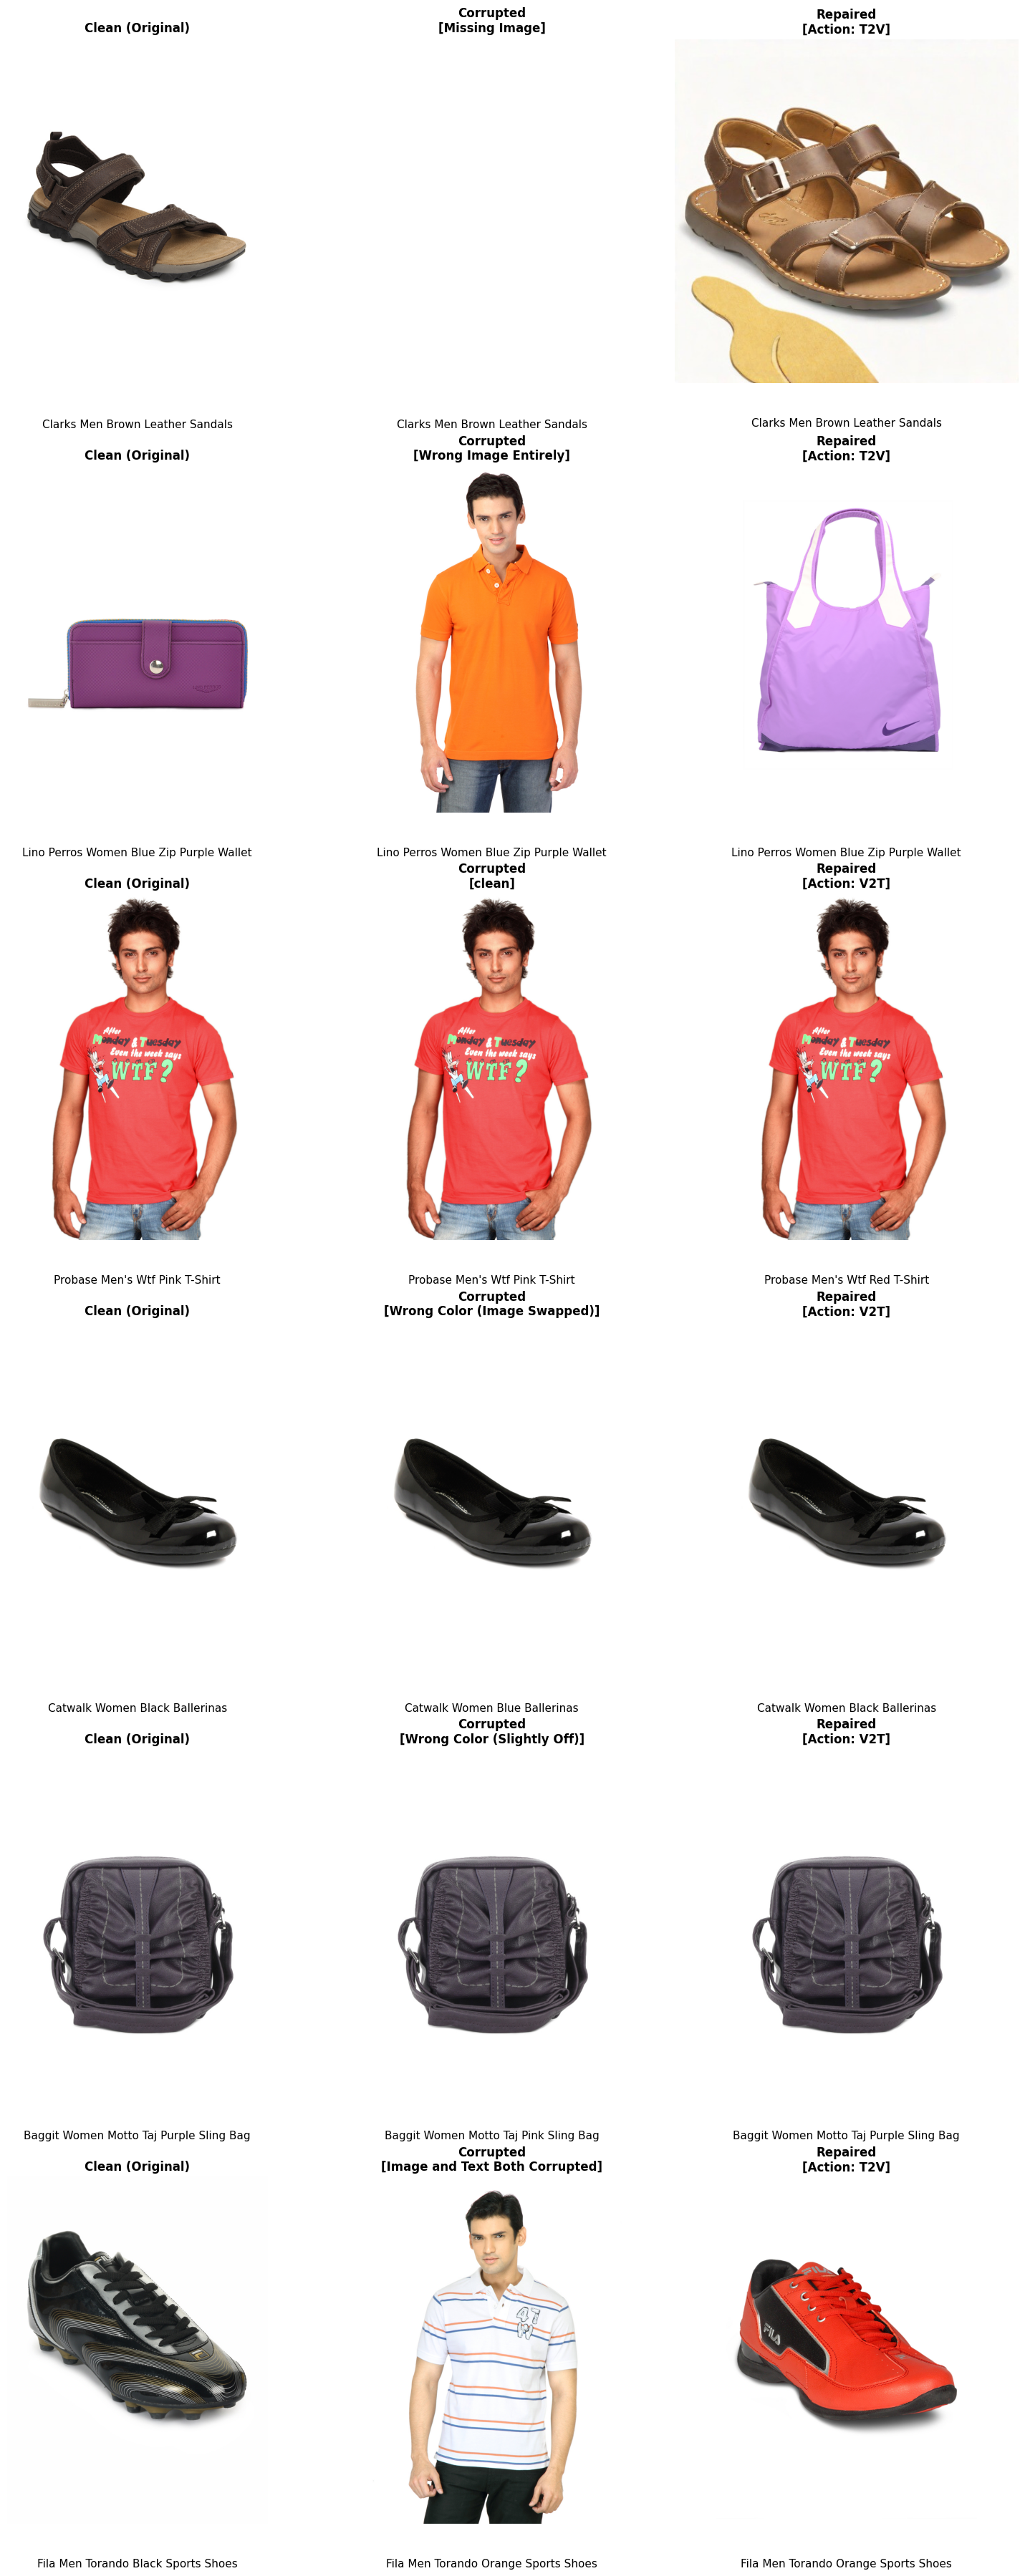

In [13]:
# Visual Inspection: See the Clean -> Corrupted -> Repaired progression
from tiger.viz import plot_repair_stages
plot_repair_stages(seed=7)


### Step 15: Repair Ablation Study
This command takes 20 corrupted products and runs them through the repair cycle 5 different times, turning off a different component each time to see what breaks:

Full System: Runs normally as a baseline.
No Arbiter: Turns off our trained AI router and forces the system to guess randomly. (Proves the Arbiter is necessary).
No VLM Judge: Turns off Gemini. (Proves that without a VLM, the system accepts visually wrong images).
No Generative Fallback: Turns off Stable Diffusion. (Proves that without it, missing images become dead-ends).
No Gamma Gate: Forces the system to blindly trust the Arbiter even when it is uncertain. (Proves that our confidence threshold prevents bad automated repairs).

In [14]:
!python -m tiger.cli ablate-repair --vlm-judge --generative-fallback 


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|█████████████| 7/7 [00:01<00:00,  6.04it/s]
  Sampled 450 corrupted + 900 clean = 1350 total rows

Running repair ablations on the full dataset...
1/5: Running 'Full System'...
[Generative Fallback] Synthesizing (SDXL-Turbo): 'Baggit Brown Handbag. Category: bags. Attributes: color=brown.'
[Generative Fallback] Synthesizing (SDXL-Turbo): 'Carlton London Women Blue & Cream Shoes. Category: shoes. Attr

In [15]:
!python -m tiger.cli ablate-repair --independent --generative-fallback


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|█████████████| 7/7 [00:01<00:00,  6.24it/s]
  Sampled 450 corrupted + 900 clean = 1350 total rows

Running repair ablations on the full dataset...
1/5: Running 'Full System'...
[Generative Fallback] Synthesizing (SDXL-Turbo): 'Red Tape Men's Black Formal Shoe. Category: shoes. Attributes: color=black.'
[Generative Fallback] Synthesizing (SDXL-Turbo): 'Lino Perros Women Blue Handbag. Category: bags. A